In [2]:
#install if unavailable
!pip install html5lib

     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/112.2 kB ? eta -:--:--
     ---------- -----------------------------

In [1]:
import numpy as np
import os
import pandas as pd
from skimage import io, color, exposure, img_as_float32
import skimage.transform
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def createTarget(df):
    df['Labels'] = [[0,0,0,0,0,0,0] for i in range (0,len(df))] #create a column for labels with 8 0s
    target_columns = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    label = [] #create empty label array
    for i in range(0, len(df)):
        for target in target_columns:
            label.append(df.loc[i, target]) #append the value for the column for each row to the label
        
        df.at[i,'Labels'] = label #update the label column with the label array
        label = [] #reset label array
            

In [4]:
df = pd.read_excel("../Processed_data.xlsx")

In [5]:
createTarget(df)

In [6]:
df.head()

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O,Labels
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0]"
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0,"[1, 0, 0, 0, 0, 0, 0, 0]"
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1,"[0, 1, 0, 0, 0, 0, 0, 1]"
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0,"[1, 0, 0, 0, 0, 0, 0, 0]"
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 1]"


In [7]:
df = df[['Patient Age', 'Filename', 'Labels']] #select the relevant columns

In [8]:
df

,Patient Age,Filename,Labels
0,69,0_left.jpg,"[0, 0, 0, 1, 0, 0, 0, 0]"
1,57,1_left.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
2,42,2_left.jpg,"[0, 1, 0, 0, 0, 0, 0, 1]"
3,66,3_left.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
4,53,4_left.jpg,"[0, 0, 0, 0, 0, 0, 0, 1]"
...,...,...,...
6995,63,4686_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"
6996,42,4688_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"
6997,54,4689_right.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
6998,57,4690_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"


In [9]:
bins = [0, 20,30,40,50,60,70,80,100] #bins for age
labels = ['<=20','21-30','31-40','41-50','51-60','61-70','71-80','80+'] #labels for bins

df['Patient Age'] = pd.cut(df['Patient Age'], bins = bins, labels = labels, right=True)

In [10]:
df

,Patient Age,Filename,Labels
0,61-70,0_left.jpg,"[0, 0, 0, 1, 0, 0, 0, 0]"
1,51-60,1_left.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
2,41-50,2_left.jpg,"[0, 1, 0, 0, 0, 0, 0, 1]"
3,61-70,3_left.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
4,51-60,4_left.jpg,"[0, 0, 0, 0, 0, 0, 0, 1]"
...,...,...,...
6995,61-70,4686_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"
6996,41-50,4688_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"
6997,51-60,4689_right.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
6998,51-60,4690_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 0]"


In [11]:
#One hot encode the age
one_hot = OneHotEncoder()

In [12]:
column_transformer = ColumnTransformer(
    transformers=[
        ('One Hot ', one_hot, ['Patient Age'])
    ],remainder='passthrough')

In [13]:
df = pd.DataFrame(column_transformer.fit_transform(df), columns=column_transformer.get_feature_names_out(df.columns))

In [14]:
for col in df:
    if col[0:10] == "One Hot __":
        df.rename(columns={col:col[10:]},inplace=True)
    elif col[0:11] == "remainder__":
        df.rename(columns={col:col[11:]},inplace=True)

In [15]:
df.columns

Index(['Patient Age_21-30', 'Patient Age_31-40', 'Patient Age_41-50',
       'Patient Age_51-60', 'Patient Age_61-70', 'Patient Age_71-80',
       'Patient Age_80+', 'Patient Age_<=20', 'Filename', 'Labels'],
      dtype='object')

Reading the Images for testing random forest on just raw images

In [22]:
path_to_images = "../ocular-disease-recognition-odir5k/"
training_path = "ODIR-5k/ODIR-5k/Training Images/"
pre_image_path = path_to_images + training_path

In [23]:
y = y = df['Labels'].apply(lambda x: np.array(x))
y = np.array(y.tolist()) 
X = df['Filename']
X_filename_train, X_filename_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

In [24]:
def read_image(location):
    img = img_as_float32(io.imread(os.path.join(pre_image_path + location)))
    img = color.rgba2rgb(img) if img.shape[-1] == 4 else img
    img = skimage.transform.resize(img, (128, 128), anti_aliasing=True)
    img = exposure.rescale_intensity(img, out_range = (0,1))
    return img.flatten()

In [25]:
def train_random_forest(X_train, y_train, rf_classifier, batch_size=100):
    
    for i in range(0, len(X_train), batch_size):
        files = X_train.iloc[i:i+batch_size]
        labels = y_train[i: i+ batch_size]
        images = [read_image(file) for file in files]
        print("I am training: ",i,' batch')
        rf_classifier.fit(images, labels)
#         print("I am done training")
    return rf_classifier
        

In [26]:
classifier = RandomForestClassifier(random_state=42)
classifier_age = RandomForestClassifier(random_state=42)
multi_target_decision = MultiOutputClassifier(classifier, n_jobs=2)
multi_target_decision_age = MultiOutputClassifier(classifier, n_jobs=2)

In [ ]:
rf_classifier = train_random_forest(X_filename_train, y_train, multi_target_decision)

In [56]:
def predict_random_forest(X_test, rf_classifier, batch_size=100):
    pred = []
    for i in range(0, len(X_test), batch_size):
        files = X_test.iloc[i:i+batch_size]
        labels = y_test[i: i+ batch_size]
        images = [read_image(file) for file in files]
        preds = rf_classifier.predict(images)
        pred.extend(preds)

    return pred

In [57]:
predictions = predict_random_forest(X_filename_test, rf_classifier)

In [61]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.53      0.36      0.43       655
           1       0.42      0.06      0.10       351
           2       0.17      0.07      0.10        76
           3       0.00      0.00      0.00        57
           4       0.00      0.00      0.00        53
           5       0.00      0.00      0.00        35
           6       0.50      0.04      0.07        52
           7       0.17      0.09      0.12       233

   micro avg       0.42      0.19      0.26      1512
   macro avg       0.22      0.08      0.10      1512
weighted avg       0.38      0.19      0.24      1512
 samples avg       0.19      0.20      0.19      1512



C:\Users\mimiw\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [58]:
acc = [1 if (y_test[i] == predictions[i]).all() else 0 for i in range(0,len(y_test))]

In [60]:
sum(acc)/len(acc)

0.16714285714285715

Random Forest on Raw Images + Age Columns

In [17]:
df.columns

Index(['Patient Age_21-30', 'Patient Age_31-40', 'Patient Age_41-50',
       'Patient Age_51-60', 'Patient Age_61-70', 'Patient Age_71-80',
       'Patient Age_80+', 'Patient Age_<=20', 'Filename', 'Labels'],
      dtype='object')

In [62]:
y = y = df['Labels'].apply(lambda x: np.array(x))
y = np.array(y.tolist()) 
X = df.drop('Labels', axis=1)
X_filename_train, X_filename_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

In [40]:
def train_random_forest_age(X_train, y_train, rf_classifier, batch_size=100):
    for i in range(0, len(X_train), batch_size):
        X_tabular = X_train.iloc[i:i+batch_size].copy()
        X_images = X_tabular['Filename'].apply(read_image)
        X_tabular.drop('Filename', axis=1, inplace=True)

        # Combine tabular and image data
        X_combined = np.concatenate((X_tabular.values, np.vstack(X_images)), axis=1)

        labels = y_train[i:i+batch_size]

        print("I am training: ", i, ' batch')
        rf_classifier.fit(X_combined, labels)

    return rf_classifier

In [41]:
rf_classifier_age = train_random_forest_age(X_filename_train, y_train, multi_target_decision_age)

I am training:  0  batch
I am training:  100  batch
I am training:  200  batch
I am training:  300  batch
I am training:  400  batch
I am training:  500  batch
I am training:  600  batch
I am training:  700  batch
I am training:  800  batch
I am training:  900  batch
I am training:  1000  batch
I am training:  1100  batch
I am training:  1200  batch
I am training:  1300  batch
I am training:  1400  batch
I am training:  1500  batch
I am training:  1600  batch
I am training:  1700  batch
I am training:  1800  batch
I am training:  1900  batch
I am training:  2000  batch
I am training:  2100  batch
I am training:  2200  batch
I am training:  2300  batch
I am training:  2400  batch
I am training:  2500  batch
I am training:  2600  batch
I am training:  2700  batch
I am training:  2800  batch
I am training:  2900  batch
I am training:  3000  batch
I am training:  3100  batch
I am training:  3200  batch
I am training:  3300  batch
I am training:  3400  batch
I am training:  3500  batch
I am

In [64]:
def predict_random_forest_age(X_test, rf_classifier, batch_size=100):
    pred = []
    for i in range(0, len(X_test), batch_size):
        X_tabular = X_test.iloc[i:i+batch_size].copy()
        X_images = X_tabular['Filename'].apply(read_image)
        X_tabular.drop('Filename', axis=1, inplace=True)

        # Combine tabular and image data
        X_combined = np.concatenate((X_tabular.values, np.vstack(X_images)), axis=1)
        preds = rf_classifier.predict(X_combined)
        pred.extend(preds)

    return pred

In [65]:
predictions = predict_random_forest_age(X_filename_test, rf_classifier_age)

In [66]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.52      0.36      0.42       655
           1       0.38      0.06      0.10       351
           2       0.23      0.09      0.13        76
           3       1.00      0.02      0.03        57
           4       0.00      0.00      0.00        53
           5       0.00      0.00      0.00        35
           6       0.67      0.04      0.07        52
           7       0.14      0.07      0.09       233

   micro avg       0.42      0.19      0.26      1512
   macro avg       0.37      0.08      0.11      1512
weighted avg       0.41      0.19      0.23      1512
 samples avg       0.19      0.19      0.19      1512



C:\Users\mimiw\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [67]:
acc = [1 if (y_test[i] == predictions[i]).all() else 0 for i in range(0,len(y_test))]

In [68]:
sum(acc)/len(acc)

0.16214285714285714

## Analysis
A brief analysis of all the tree models used in this project. All relevant notebooks are in the same folder as this one. 

In [5]:
data = [
    ["Decision Tree", "No Age", "15.81%", "0.33"],
    ["Decision Tree", "No Age + PCA", "15.14%", "0.33"],
    ["Decision Tree", "Age", "17.57%", "0.35"],
    ["Decision Tree (Baseline)", "Columnal (Age)", "99.9%", "1.0"],
    ["Decision Tree (Baseline)", "Columnal (No Age)", "99.9%", "1.0"],
    ["Random Forest", "No Age", "16.7%", "0.26"],
    ["Random Forest", "Age", "16.2%", "0.26"],
    ["XGBoost Images", "No Age", "26.24%", None],
    ["XGBoost Images", "Age", "25.19%", None],
]

# Create a list of column names
columns = ["Model", "Feature", "Accuracy", "F1 Score"]

# Create a DataFrame
df = pd.DataFrame(data, columns=columns)

# Display the DataFrame
df.head()


,Model,Feature,Accuracy,F1 Score
0,Decision Tree,No Age,15.81%,0.33
1,Decision Tree,No Age + PCA,15.14%,0.33
2,Decision Tree,Age,17.57%,0.35
3,Decision Tree (Baseline),Columnal (Age),99.9%,1.0
4,Decision Tree (Baseline),Columnal (No Age),99.9%,1.0


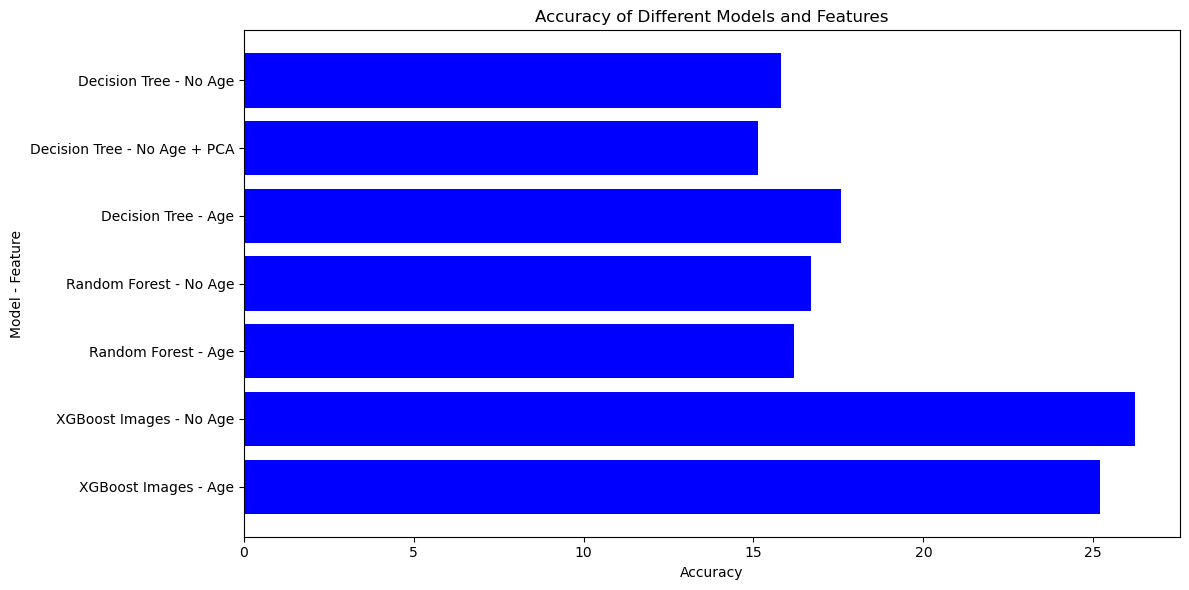

In [8]:
import matplotlib.pyplot as plt

# Assuming df_filtered is your DataFrame

plt.figure(figsize=(12, 6))  # Increase the figure width

# Use a horizontal bar plot to make longer labels more readable
plt.barh(df_filtered['Model'] + ' - ' + df_filtered['Feature'], df_filtered['Accuracy'], color='blue')
plt.xlabel('Accuracy')
plt.ylabel('Model - Feature')
plt.title('Accuracy of Different Models and Features')
plt.tight_layout()

# Invert y-axis to have the highest accuracy at the top
plt.gca().invert_yaxis()

plt.show()
